EXPERIMENT - 7 DEVELOP SVM MODEL

Title: Develop SVM model Problem Background A leading bank in Pune wants to automate its loan approval process. Currently, loan approval decisions are made manually by loan officers, which is time-consuming and prone to inconsistency. To improve efficiency and accuracy, the bank plans to build a Machine Learning classification model using Support Vector Machine (SVM) to predict whether a loan application should be Approved (1) or Rejected (0).

Develop an SVM classification model that can:  Classify loan applications into:
o Class 1 → Loan Approved
o Class 0 → Loan Rejected

Maximize classification accuracy.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [ ]:
data = pd.read_csv("/Bank_Loan_Approval_Dataset.csv")
print(data.head())

   Applicant_Income  Coapplicant_Income  Loan_Amount  Loan_Term_Months  \
0            136958               26736       580089               300   
1            146932                 854       200262               300   
2            118694               38623       492905               240   
3            134879                7392       285362               120   
4            125268               55680       494209                60   

   Credit_Score Employment_Type  Existing_Liabilities Property_Area  Age  \
0           369   Self-employed                210977         Urban   38   
1           551        Salaried                 12910         Rural   47   
2           714   Self-employed                335623         Rural   54   
3           744        Salaried                470951    Semi-Urban   47   
4           481   Self-employed                 81264    Semi-Urban   37   

   Loan_Status  
0            0  
1            0  
2            0  
3            0  
4            

1. Preprocess the data:

Preprocess data including Feature scaling Visualize / plot the dataset to analyze its behavior

In [ ]:
data = data.dropna()
data = pd.get_dummies(data, drop_first=True)
X = data.drop("Loan_Status", axis=1)  # target column
y = data["Loan_Status"]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

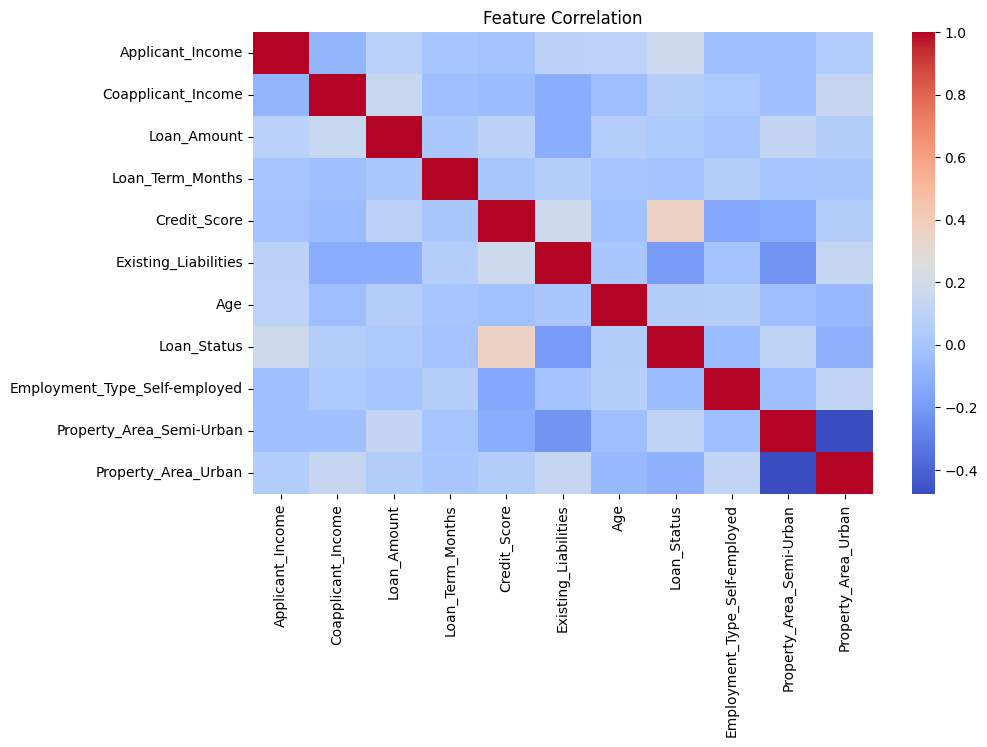

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=False, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

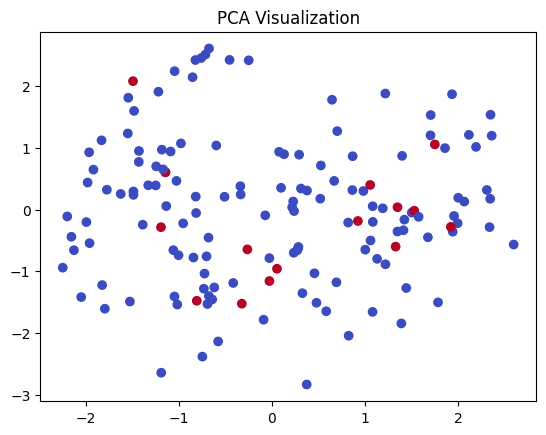

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='coolwarm')
plt.title("PCA Visualization")
plt.show()

2. Train SVM models using:

o Linear Kernel o RBF Kernel (Gaussian) o Polynomial Kernel

In [ ]:
svm_linear = SVC(kernel='linear', C=1)
svm_linear.fit(X_train, y_train)

SVC(C=1, kernel='linear')

In [ ]:
svm_rbf = SVC(kernel='rbf', C=1, gamma='scale')
svm_rbf.fit(X_train, y_train)

SVC(C=1)

In [ ]:
svm_poly = SVC(kernel='poly', degree=3, C=1)
svm_poly.fit(X_train, y_train)

SVC(C=1, kernel='poly')

3. Tune hyperparameters:

o C (Regularization parameter) o Gamma (Kernel coefficient)

In [ ]:
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': [1, 0.1, 0.01],
    'kernel': ['rbf', 'poly', 'linear']
}

grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=2)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.0s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.0s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.0s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.0s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=1, 

4. Evaluate model performance using:

o Confusion Matrix o Accuracy o Precision o Recall o F1-score

In [ ]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("Accuracy:", accuracy_score(y_test, y_pred))


5. Compare kernel performance.

In [ ]:
print("Linear Kernel")
evaluate_model(svm_linear, X_test, y_test)

print("\nRBF Kernel")
evaluate_model(svm_rbf, X_test, y_test)

print("\nPolynomial Kernel")
evaluate_model(svm_poly, X_test, y_test)

print("\nBest Model (GridSearch)")
evaluate_model(grid.best_estimator_, X_test, y_test)

Linear Kernel
Confusion Matrix:
 [[25  1]
 [ 2  2]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.96      0.94        26
           1       0.67      0.50      0.57         4

    accuracy                           0.90        30
   macro avg       0.80      0.73      0.76        30
weighted avg       0.89      0.90      0.89        30

Accuracy: 0.9

RBF Kernel
Confusion Matrix:
 [[26  0]
 [ 4  0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      1.00      0.93        26
           1       0.00      0.00      0.00         4

    accuracy                           0.87        30
   macro avg       0.43      0.50      0.46        30
weighted avg       0.75      0.87      0.80        30

Accuracy: 0.8666666666666667

Polynomial Kernel
Confusion Matrix:
 [[26  0]
 [ 4  0]]

Classification Report:
               precision    recall  f1-score   support

           0  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m